In [5]:
!pip install pandas numpy matplotlib seaborn statsmodels -q
!pip install prophet scikit-learn pmdarima plotly -q
print("All libraries installed!")

All libraries installed!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
os.makedirs('outputs', exist_ok=True)
print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
df = pd.read_csv('AEP_hourly.csv',
                 parse_dates=['Datetime'],
                 index_col='Datetime')

# Fix: sort and remove duplicate timestamps
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

print("Shape:", df.shape)
print("Index sorted     :", df.index.is_monotonic_increasing)
print("Duplicates left  :", df.index.duplicated().sum())
print("Date range:", df.index.min(), "to", df.index.max())
print(df.head())

Shape: (121269, 1)
Index sorted     : True
Duplicates left  : 0
Date range: 2004-10-01 01:00:00 to 2018-08-03 00:00:00
                      AEP_MW
Datetime                    
2004-10-01 01:00:00  12379.0
2004-10-01 02:00:00  11935.0
2004-10-01 03:00:00  11692.0
2004-10-01 04:00:00  11597.0
2004-10-01 05:00:00  11681.0


In [12]:
print("Missing values:", df.isnull().sum().values[0])
print("Total rows    :", len(df))
print("Missing %     :", round(df.isnull().sum().values[0] / len(df) * 100, 2))
print("Duplicate timestamps:", df.index.duplicated().sum())
print("Index sorted        :", df.index.is_monotonic_increasing)


Missing values: 0
Total rows    : 121269
Missing %     : 0.0
Duplicate timestamps: 0
Index sorted        : True


In [13]:
df_daily  = df.resample('D').mean()
df_weekly = df.resample('W').mean()

# Ensure complete date range with no gaps
df_daily = df_daily.asfreq('D')

# Fill missing values
df_daily = df_daily.fillna(method='ffill', limit=2)
df_daily = df_daily.interpolate(method='linear')

print("Daily data shape :", df_daily.shape)
print("Weekly data shape:", df_weekly.shape)
print("Missing after fill:", df_daily.isnull().sum().values[0])


Daily data shape : (5055, 1)
Weekly data shape: (723, 1)
Missing after fill: 0


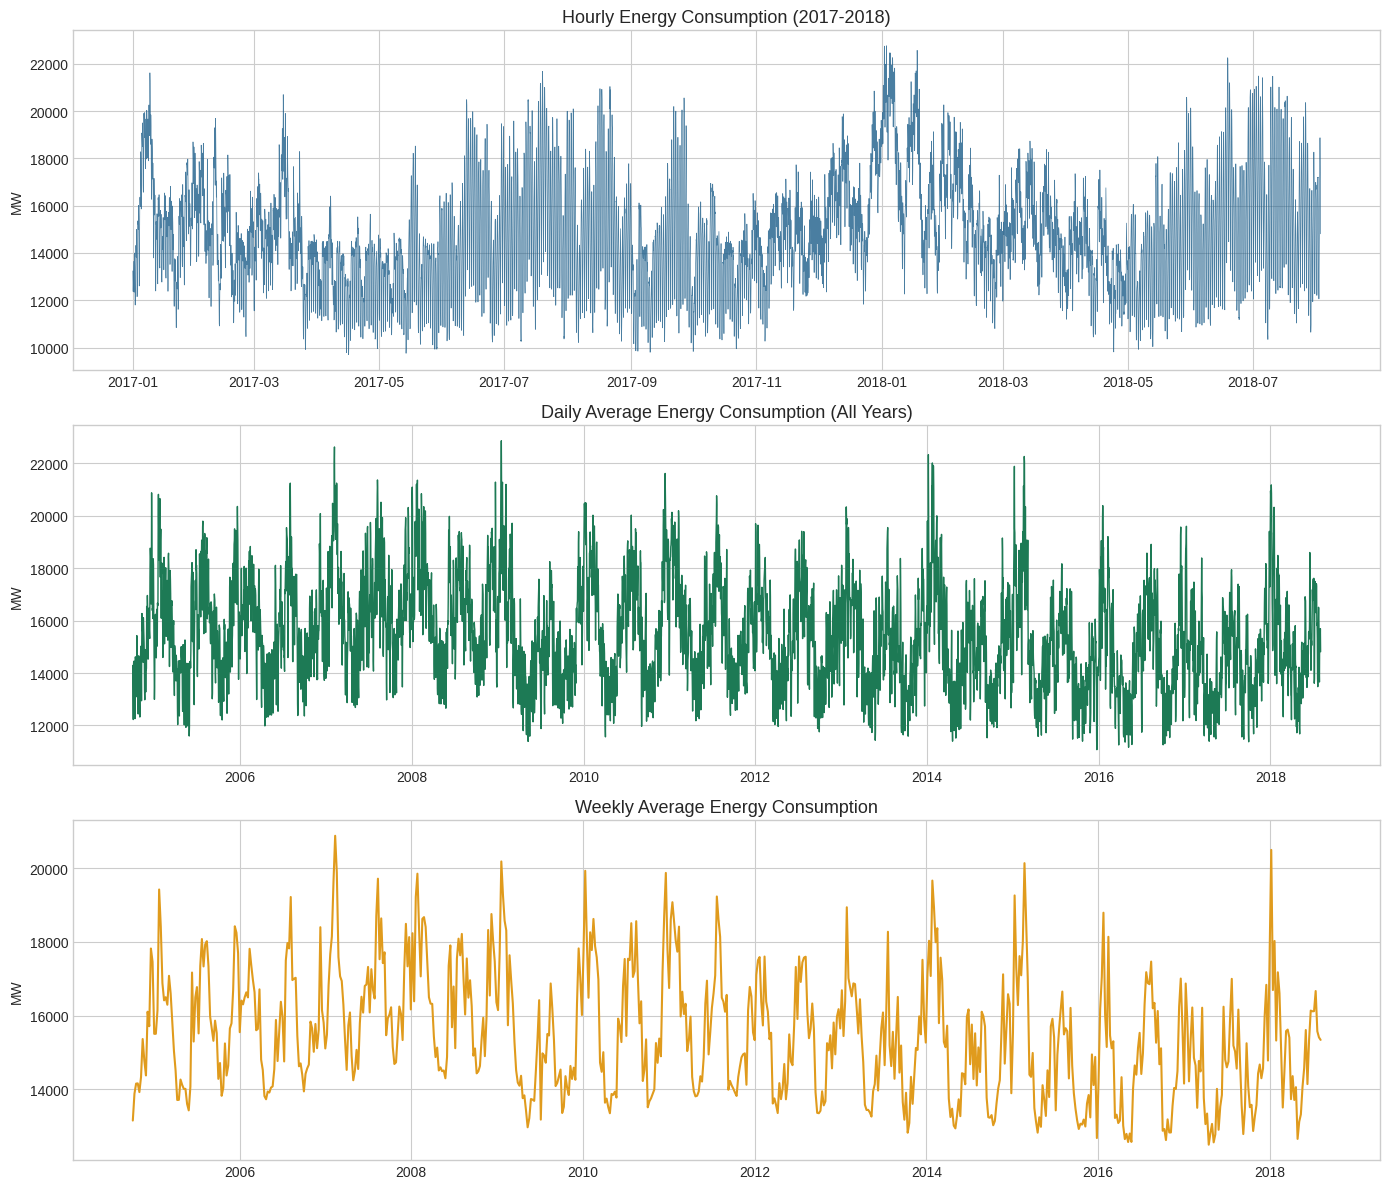

Plot saved: outputs/01_raw_consumption.png


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Hourly (1 year for clarity)
axes[0].plot(df['2017':'2018']['AEP_MW'],
             color='#1D5E8A', linewidth=0.5, alpha=0.8)
axes[0].set_title('Hourly Energy Consumption (2017-2018)', fontsize=13)
axes[0].set_ylabel('MW')

# Daily
axes[1].plot(df_daily['AEP_MW'], color='#1D7A55', linewidth=1)
axes[1].set_title('Daily Average Energy Consumption (All Years)', fontsize=13)
axes[1].set_ylabel('MW')

# Weekly
axes[2].plot(df_weekly['AEP_MW'], color='#E09B1D', linewidth=1.5)
axes[2].set_title('Weekly Average Energy Consumption', fontsize=13)
axes[2].set_ylabel('MW')

plt.tight_layout()
plt.savefig('outputs/01_raw_consumption.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/01_raw_consumption.png")


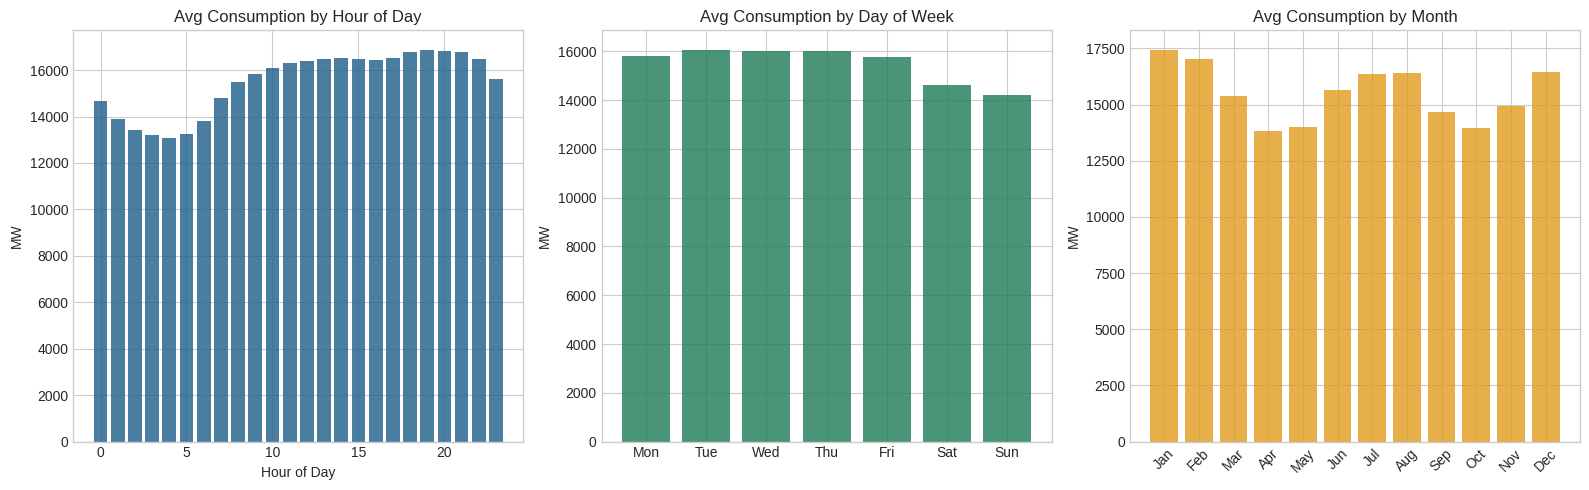

Plot saved: outputs/02_seasonality_patterns.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By hour of day
df['hour'] = df.index.hour
hourly_avg = df.groupby('hour')['AEP_MW'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='#1D5E8A', alpha=0.8)
axes[0].set_title('Avg Consumption by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('MW')

# By day of week
df['dayofweek'] = df.index.dayofweek
dow_avg = df.groupby('dayofweek')['AEP_MW'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, dow_avg.values, color='#1D7A55', alpha=0.8)
axes[1].set_title('Avg Consumption by Day of Week')
axes[1].set_ylabel('MW')

# By month
df['month'] = df.index.month
monthly_avg = df.groupby('month')['AEP_MW'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(months, monthly_avg.values, color='#E09B1D', alpha=0.8)
axes[2].set_title('Avg Consumption by Month')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('MW')

plt.tight_layout()
plt.savefig('outputs/02_seasonality_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/02_seasonality_patterns.png")


In [16]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Test: {name}")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Critical Values: 1%={result[4]['1%']:.3f}, "
          f"5%={result[4]['5%']:.3f}, 10%={result[4]['10%']:.3f}")
    if result[1] < 0.05:
        print("  RESULT: STATIONARY (reject H0) -> Good to use!")
    else:
        print("  RESULT: NON-STATIONARY (fail to reject H0) -> Apply differencing!")
    print()

# Test original series
adf_test(df_daily['AEP_MW'], 'Original Series')

# Test first difference
adf_test(df_daily['AEP_MW'].diff(), '1st Difference')


ADF Test: Original Series
  Test Statistic : -7.4874
  p-value        : 0.0000
  Critical Values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  RESULT: STATIONARY (reject H0) -> Good to use!

ADF Test: 1st Difference
  Test Statistic : -16.2227
  p-value        : 0.0000
  Critical Values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  RESULT: STATIONARY (reject H0) -> Good to use!



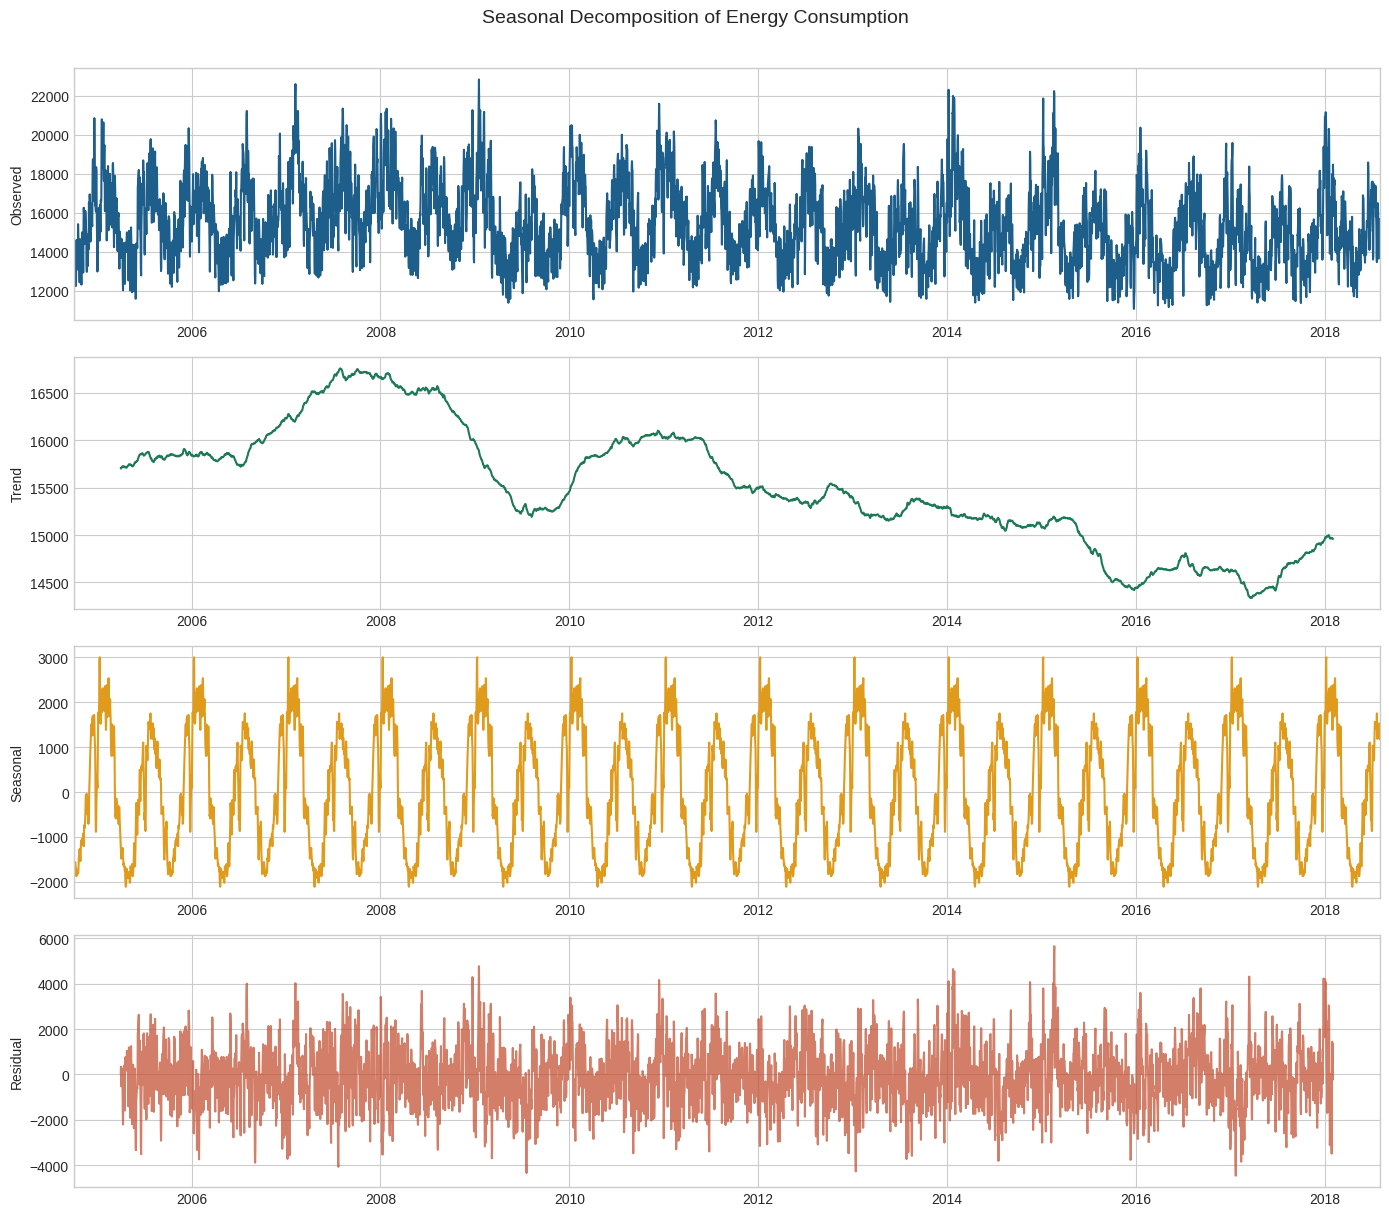

Plot saved: outputs/03_decomposition.png


In [17]:
decomp = seasonal_decompose(
    df_daily['AEP_MW'],
    model='additive',
    period=365       # yearly seasonality
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomp.observed.plot(ax=axes[0], color='#1D5E8A')
axes[0].set_ylabel('Observed')

decomp.trend.plot(ax=axes[1], color='#1D7A55')
axes[1].set_ylabel('Trend')

decomp.seasonal.plot(ax=axes[2], color='#E09B1D')
axes[2].set_ylabel('Seasonal')

decomp.resid.plot(ax=axes[3], color='#C04828', alpha=0.7)
axes[3].set_ylabel('Residual')

for ax in axes:
    ax.set_xlabel('')

plt.suptitle('Seasonal Decomposition of Energy Consumption', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('outputs/03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/03_decomposition.png")


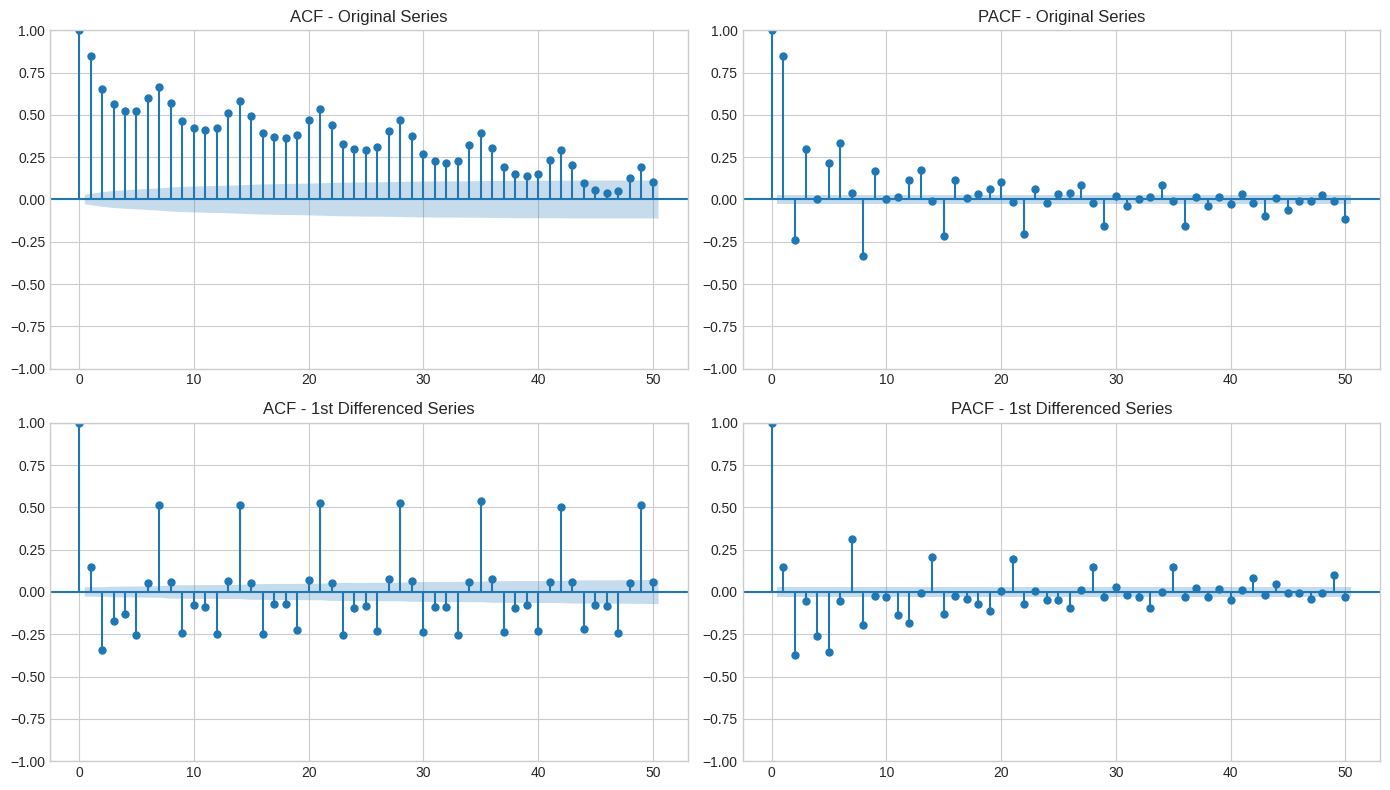

Plot saved: outputs/04_acf_pacf.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original series
plot_acf(df_daily['AEP_MW'].dropna(), lags=50, ax=axes[0, 0],
         title='ACF - Original Series')
plot_pacf(df_daily['AEP_MW'].dropna(), lags=50, ax=axes[0, 1],
          title='PACF - Original Series')

# Differenced series
diff1 = df_daily['AEP_MW'].diff().dropna()
plot_acf(diff1, lags=50, ax=axes[1, 0],
         title='ACF - 1st Differenced Series')
plot_pacf(diff1, lags=50, ax=axes[1, 1],
          title='PACF - 1st Differenced Series')

plt.tight_layout()
plt.savefig('outputs/04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/04_acf_pacf.png")


Training set: 2004-10-01 to 2017-12-31 (4840 days)
Test set    : 2018-01-01 to 2018-01-31 (31 days)


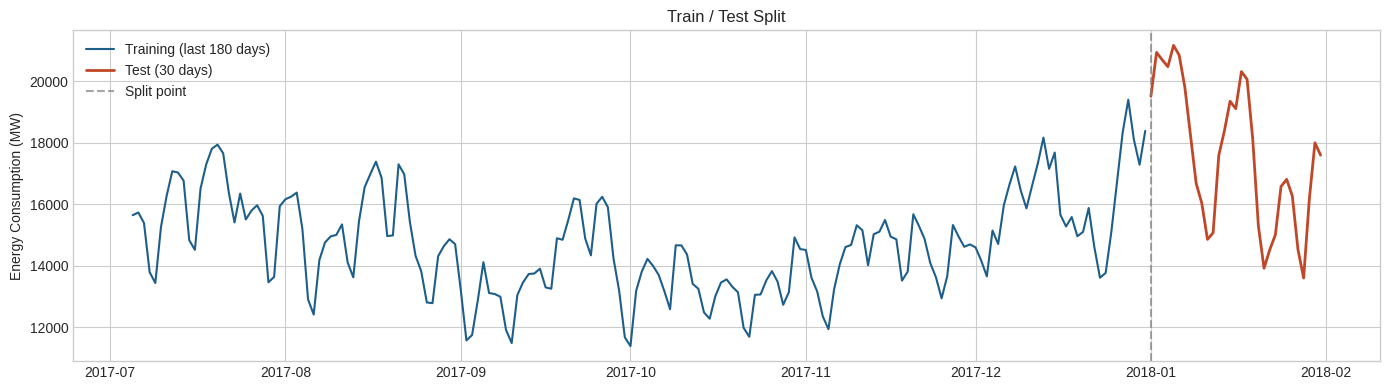

Plot saved: outputs/05_train_test_split.png


In [19]:
train = df_daily[:'2017-12-31']
test  = df_daily['2018-01-01':'2018-01-31']

print(f"Training set: {train.index.min().date()} to "
      f"{train.index.max().date()} ({len(train)} days)")
print(f"Test set    : {test.index.min().date()} to "
      f"{test.index.max().date()} ({len(test)} days)")

# Plot the split
plt.figure(figsize=(14, 4))
plt.plot(train['AEP_MW'][-180:], label='Training (last 180 days)',
         color='#1D5E8A', linewidth=1.5)
plt.plot(test['AEP_MW'], label='Test (30 days)',
         color='#C04828', linewidth=2)
plt.axvline(x=test.index[0], color='gray', linestyle='--',
            alpha=0.7, label='Split point')
plt.legend()
plt.title('Train / Test Split')
plt.ylabel('Energy Consumption (MW)')
plt.tight_layout()
plt.savefig('outputs/05_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/05_train_test_split.png")

In [20]:

print("Running auto_arima parameter search...")
print("(This may take several minutes - please wait)\n")

auto_model = auto_arima(
    train['AEP_MW'],
    start_p=1, start_q=1,
    max_p=3,   max_q=3,
    d=1,
    seasonal=True,
    m=7,                 # weekly seasonality
    start_P=0, start_Q=0,
    max_P=2,   max_Q=2,
    D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True        # faster search
)

print("\nBest model found:")
print(f"  Order         : {auto_model.order}")
print(f"  Seasonal order: {auto_model.seasonal_order}")
print(f"  AIC           : {auto_model.aic():.2f}")


Running auto_arima parameter search...
(This may take several minutes - please wait)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[7]             : AIC=80703.557, Time=3.18 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=81015.922, Time=0.23 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=79482.325, Time=5.06 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=7.33 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=80844.576, Time=0.30 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=78855.948, Time=10.81 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=25.60 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=9.34 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=79018.088, Time=1.42 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=78545.080, Time=10.64 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=79198.625, Time=5.10 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=25.70 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=14.91 sec
 ARIMA(3,1,0)(2,1,0)[7]  

In [21]:
order          = auto_model.order
seasonal_order = auto_model.seasonal_order

print(f"Fitting SARIMA{order}{seasonal_order}...")

sarima_model = SARIMAX(
    train['AEP_MW'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)
print("Done! Model summary:")
print(sarima_results.summary())



Fitting SARIMA(3, 1, 0)(2, 1, 0, 7)...
Done! Model summary:
                                     SARIMAX Results                                     
Dep. Variable:                            AEP_MW   No. Observations:                 4840
Model:             SARIMAX(3, 1, 0)x(2, 1, 0, 7)   Log Likelihood              -39103.756
Date:                           Mon, 16 Mar 2026   AIC                          78219.512
Time:                                   10:02:25   BIC                          78258.389
Sample:                               10-01-2004   HQIC                         78233.164
                                    - 12-31-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2047      0.012     17.105      0.000       0

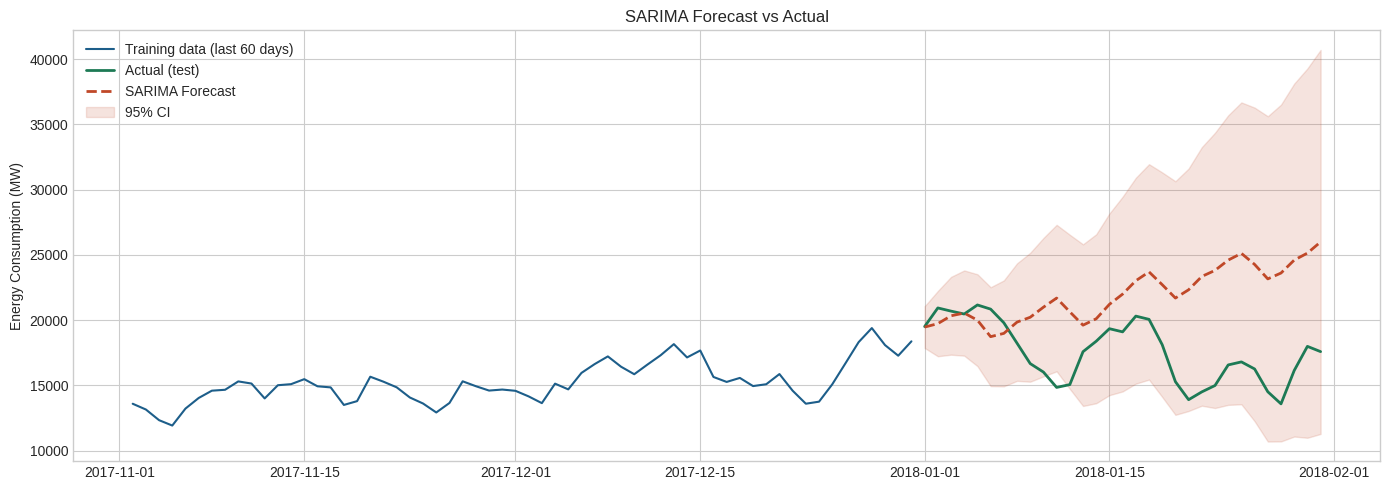

Plot saved: outputs/06_sarima_forecast.png


In [22]:
forecast_steps = len(test)
forecast       = sarima_results.get_forecast(steps=forecast_steps)
sarima_pred    = forecast.predicted_mean
conf_int       = forecast.conf_int(alpha=0.05)

# Set correct date index
sarima_pred.index = test.index
conf_int.index    = test.index

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train['AEP_MW'][-60:], label='Training data (last 60 days)',
         color='#1D5E8A', linewidth=1.5)
plt.plot(test['AEP_MW'], label='Actual (test)',
         color='#1D7A55', linewidth=2)
plt.plot(sarima_pred, label='SARIMA Forecast',
         color='#C04828', linewidth=2, linestyle='--')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.15, color='#C04828', label='95% CI')
plt.legend(loc='upper left')
plt.title('SARIMA Forecast vs Actual')
plt.ylabel('Energy Consumption (MW)')
plt.tight_layout()
plt.savefig('outputs/06_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/06_sarima_forecast.png")


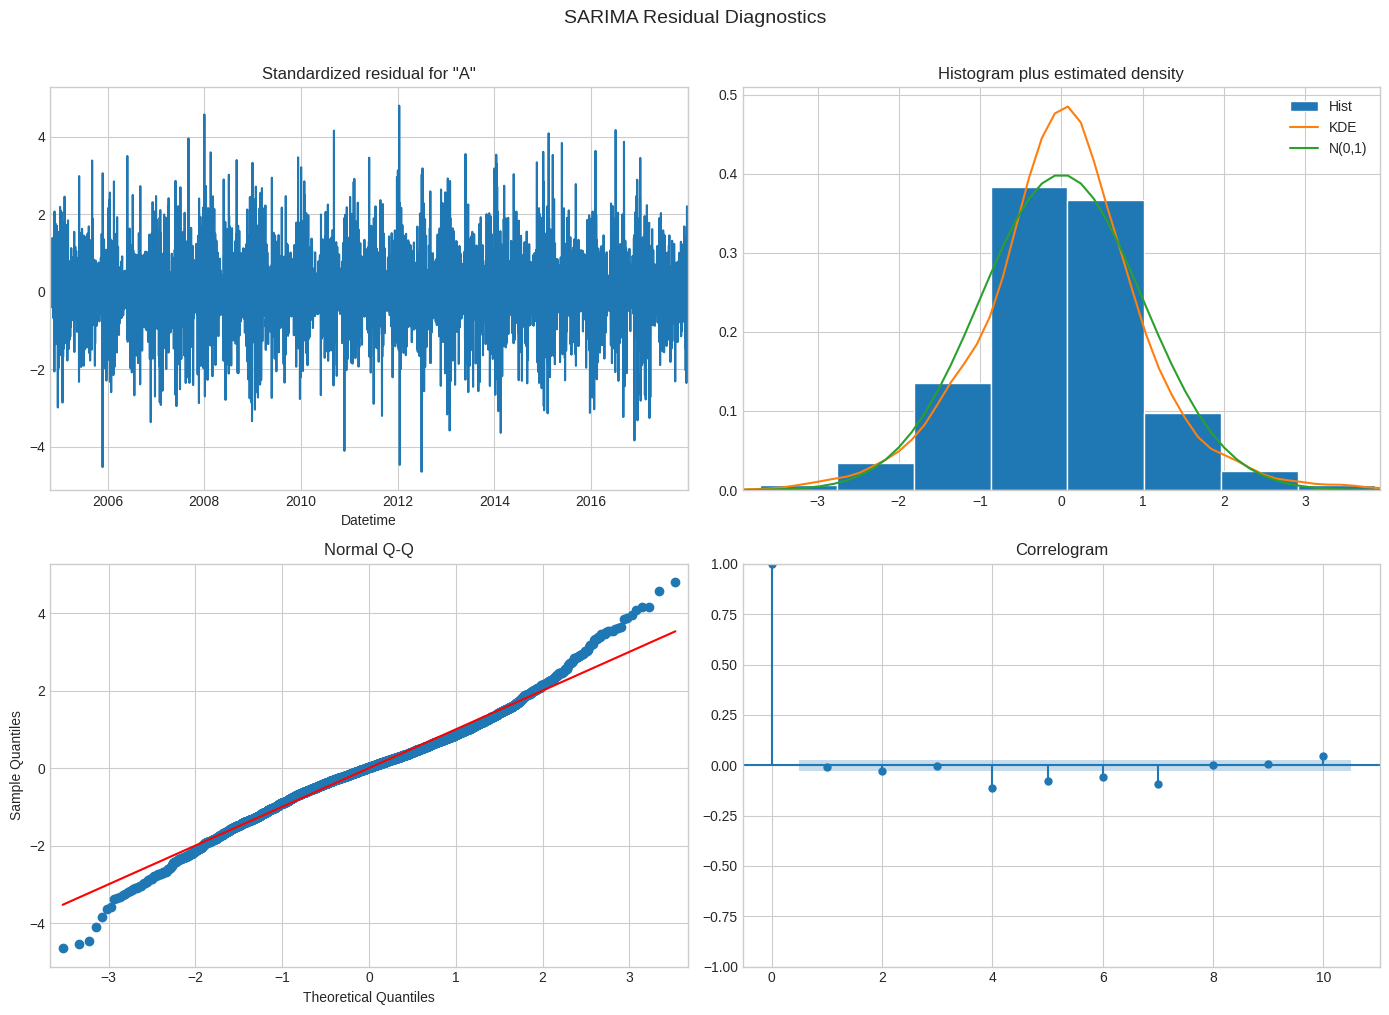


Ljung-Box Test for Residual Autocorrelation:
      lb_stat     lb_pvalue
10  162.86611  8.291965e-30

Interpretation:
  p-value > 0.05 = residuals are white noise = GOOD (no autocorrelation left)
  p-value < 0.05 = still autocorrelation in residuals = try higher p/q


In [23]:
sarima_results.plot_diagnostics(figsize=(14, 10))
plt.suptitle('SARIMA Residual Diagnostics', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('outputs/07_sarima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test
lb_test = acorr_ljungbox(sarima_results.resid, lags=[10], return_df=True)
print("\nLjung-Box Test for Residual Autocorrelation:")
print(lb_test)
print("\nInterpretation:")
print("  p-value > 0.05 = residuals are white noise = GOOD (no autocorrelation left)")
print("  p-value < 0.05 = still autocorrelation in residuals = try higher p/q")


In [24]:
# Prophet requires columns named 'ds' and 'y' exactly
df_prophet = df_daily.reset_index()
df_prophet.columns = ['ds', 'y']

# Split
prophet_train = df_prophet[df_prophet['ds'] <= '2017-12-31'].copy()
prophet_test  = df_prophet[(df_prophet['ds'] >= '2018-01-01') &
                            (df_prophet['ds'] <= '2018-01-31')].copy()

print("Prophet training set:", prophet_train.shape)
print("Prophet test set    :", prophet_test.shape)
print("\nFirst few rows:")
print(prophet_train.head())


Prophet training set: (4840, 2)
Prophet test set    : (31, 2)

First few rows:
          ds             y
0 2004-10-01  14284.521739
1 2004-10-02  12999.875000
2 2004-10-03  12227.083333
3 2004-10-04  14309.041667
4 2004-10-05  14439.708333


In [25]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,   # trend flexibility (lower = smoother)
    seasonality_prior_scale=10,     # seasonality strength
    interval_width=0.95             # 95% uncertainty interval
)

# Add US public holidays
model_prophet.add_country_holidays(country_name='US')

print("Fitting Prophet model...")
model_prophet.fit(prophet_train)
print("Done!")



Fitting Prophet model...
Done!


In [31]:
# Create future dataframe
future = model_prophet.make_future_dataframe(periods=31, freq='D')

# Generate forecast
forecast_prophet = model_prophet.predict(future)

# Extract test period predictions
prophet_pred = forecast_prophet[
    forecast_prophet['ds'] >= '2018-01-01'
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

print("Forecast shape:", forecast_prophet.shape)
print("\nTest period forecast (first 5 rows):")
print(prophet_pred.head())


Forecast shape: (4871, 64)

Test period forecast (first 5 rows):
             ds          yhat    yhat_lower    yhat_upper
4840 2018-01-01  14270.198605  11952.556552  16423.637740
4841 2018-01-02  15974.060383  13589.967311  18280.766272
4842 2018-01-03  15980.385299  13809.394926  18164.776104
4843 2018-01-04  16109.498050  13912.940462  18440.511057
4844 2018-01-05  15897.399376  13428.316587  18194.603746


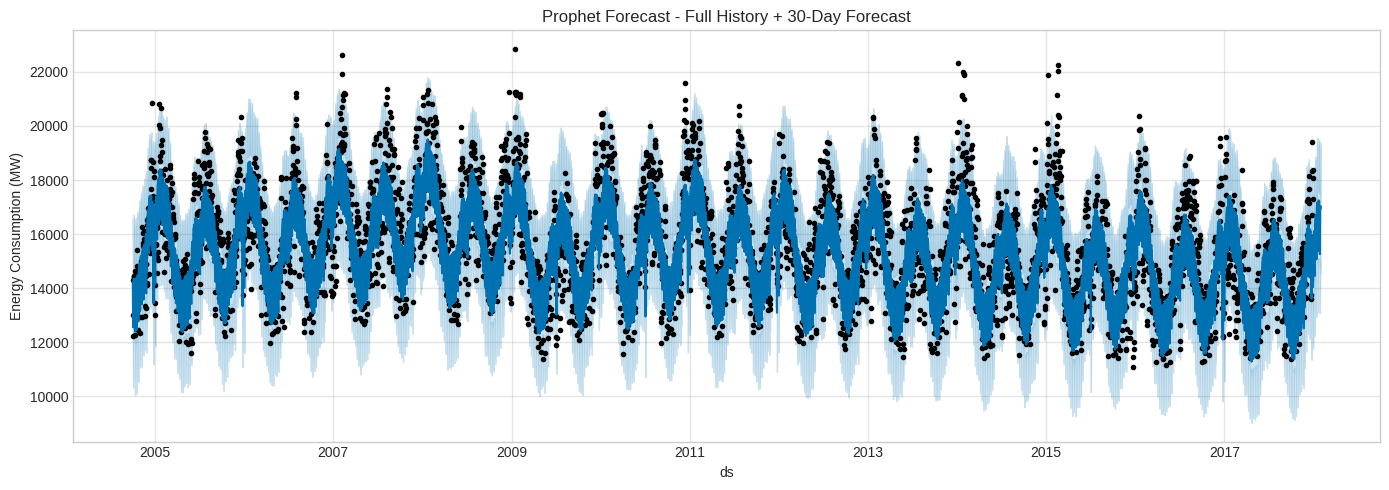

Plot saved: outputs/08_prophet_forecast_full.png


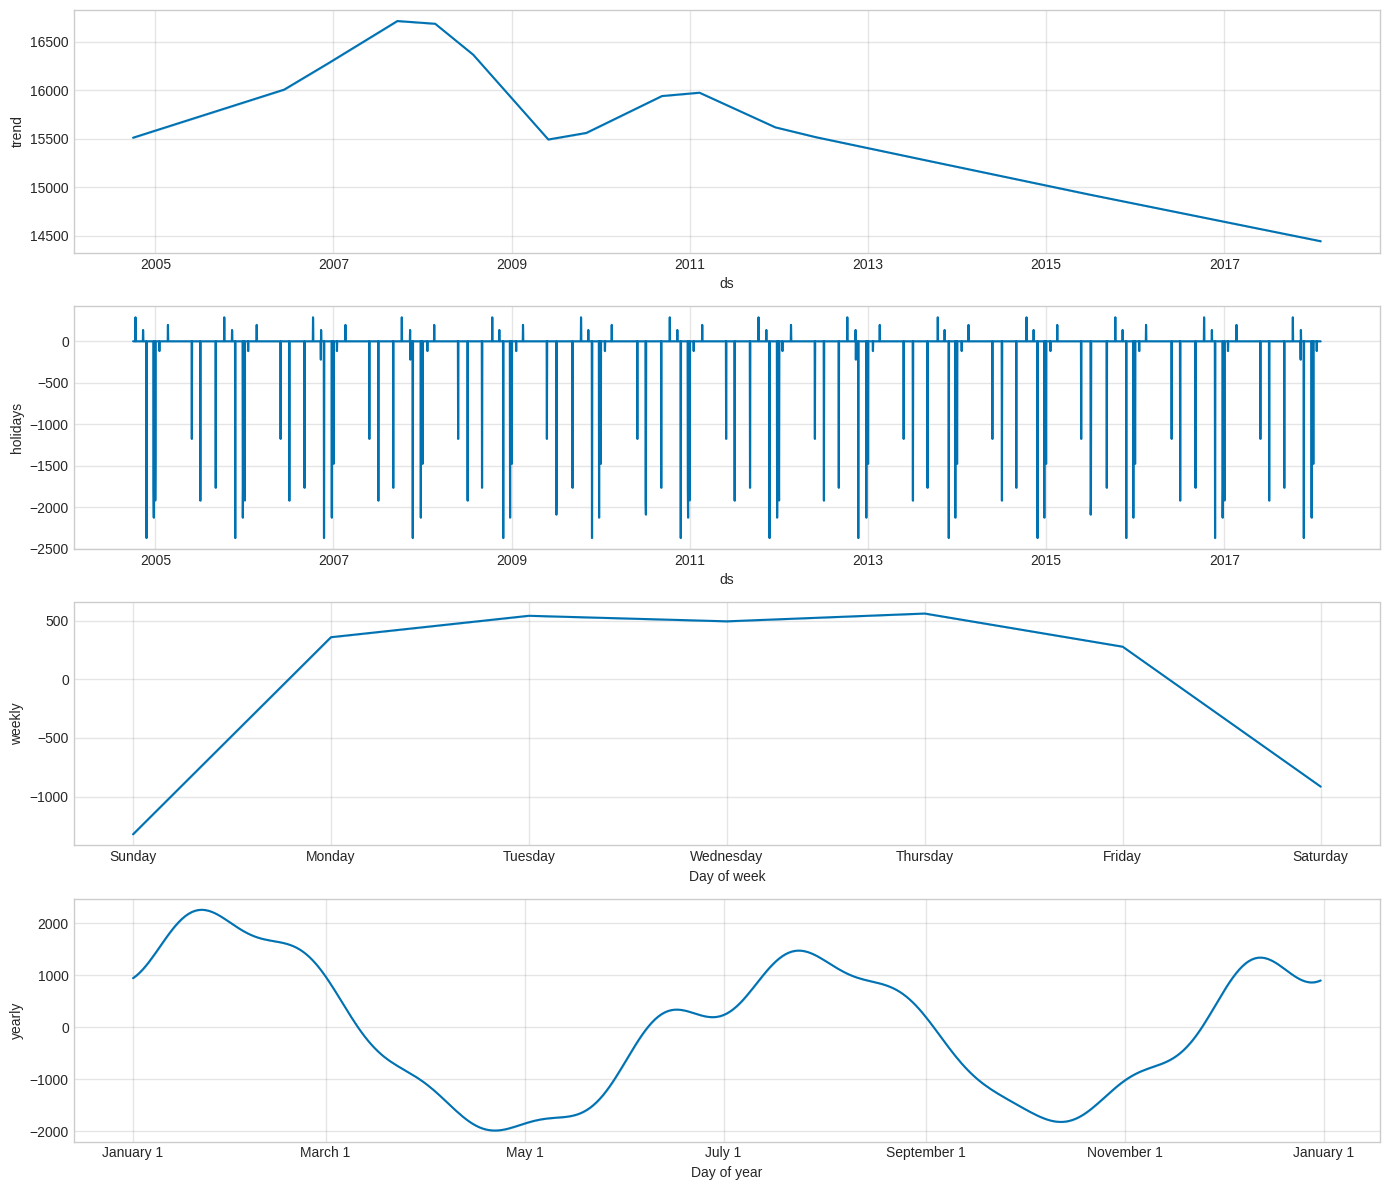

Plot saved: outputs/09_prophet_components.png


In [32]:
# Full history + forecast plot
fig1 = model_prophet.plot(forecast_prophet, figsize=(14, 5))
plt.title('Prophet Forecast - Full History + 30-Day Forecast')
plt.ylabel('Energy Consumption (MW)')
plt.tight_layout()
plt.savefig('outputs/08_prophet_forecast_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/08_prophet_forecast_full.png")

# Components plot (trend + each seasonality)
fig2 = model_prophet.plot_components(forecast_prophet, figsize=(14, 12))
plt.tight_layout()
plt.savefig('outputs/09_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/09_prophet_components.png")


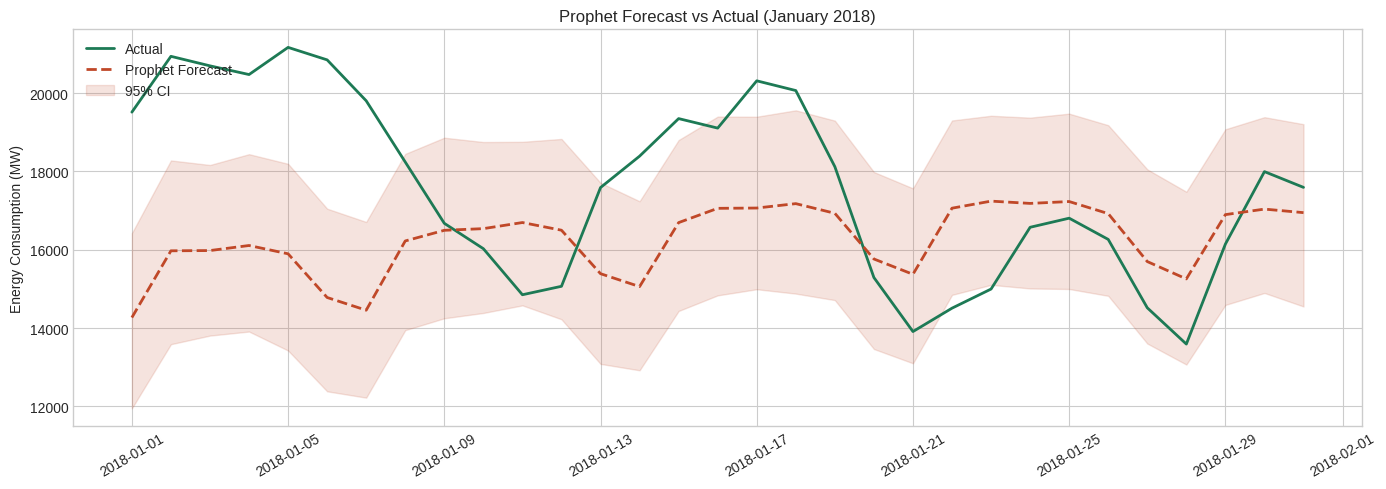

Plot saved: outputs/10_prophet_test_comparison.png


In [33]:
plt.figure(figsize=(14, 5))

plt.plot(prophet_test['ds'].values,
         prophet_test['y'].values,
         label='Actual', color='#1D7A55', linewidth=2)

plt.plot(prophet_pred['ds'].values,
         prophet_pred['yhat'].values,
         label='Prophet Forecast', color='#C04828',
         linewidth=2, linestyle='--')

plt.fill_between(prophet_pred['ds'].values,
                 prophet_pred['yhat_lower'].values,
                 prophet_pred['yhat_upper'].values,
                 alpha=0.15, color='#C04828', label='95% CI')

plt.legend(loc='upper left')
plt.title('Prophet Forecast vs Actual (January 2018)')
plt.ylabel('Energy Consumption (MW)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/10_prophet_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/10_prophet_test_comparison.png")



In [34]:
def evaluate_model(actual, predicted, model_name):
    actual    = np.array(actual)
    predicted = np.array(predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = 1 - (np.sum((actual - predicted) ** 2) /
                np.sum((actual - np.mean(actual)) ** 2))

    print(f"--- {model_name} ---")
    print(f"  RMSE : {rmse:,.2f} MW")
    print(f"  MAE  : {mae:,.2f} MW")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R2   : {r2:.4f}")
    print()

    return {'Model': model_name,
            'RMSE': round(rmse, 2),
            'MAE':  round(mae, 2),
            'MAPE': round(mape, 3),
            'R2':   round(r2, 4)}



In [35]:
# ============================================================
# CELL 22: EVALUATION METRICS  (fixed)
# ============================================================

def evaluate_model(actual, predicted, model_name):
    actual    = np.array(actual)
    predicted = np.array(predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = 1 - (np.sum((actual - predicted) ** 2) /
                np.sum((actual - np.mean(actual)) ** 2))

    print(f"--- {model_name} ---")
    print(f"  RMSE : {rmse:,.2f} MW")
    print(f"  MAE  : {mae:,.2f} MW")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R2   : {r2:.4f}")
    print()

    return {'Model': model_name,
            'RMSE': round(rmse, 2),
            'MAE' : round(mae, 2),
            'MAPE': round(mape, 3),
            'R2'  : round(r2, 4)}

# ── SARIMA evaluation ──────────────────────────────────────
actual_values  = test['AEP_MW'].values
sarima_metrics = evaluate_model(actual_values,
                                sarima_pred.values,
                                'SARIMA')

# ── Prophet evaluation (align on date first) ───────────────
# Merge actual vs forecast on the 'ds' column so lengths match
prophet_eval = prophet_test[['ds','y']].merge(
    prophet_pred[['ds','yhat']],
    on='ds',
    how='inner'          # keeps only dates present in BOTH
)

print(f"Aligned rows for Prophet evaluation: {len(prophet_eval)}")

prophet_metrics = evaluate_model(prophet_eval['y'].values,
                                  prophet_eval['yhat'].values,
                                  'Prophet')

--- SARIMA ---
  RMSE : 5,735.84 MW
  MAE  : 4,749.61 MW
  MAPE : 29.57%
  R2   : -5.1942

Aligned rows for Prophet evaluation: 31
--- Prophet ---
  RMSE : 2,922.45 MW
  MAE  : 2,358.86 MW
  MAPE : 12.75%
  R2   : -0.6080



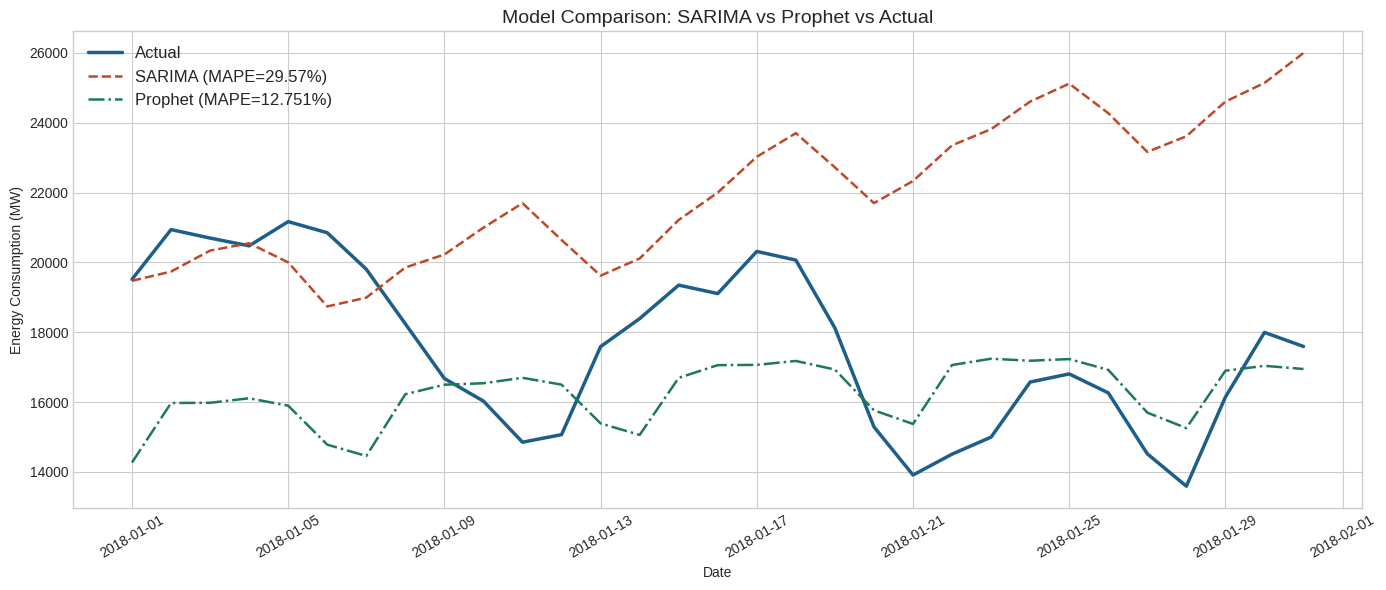

Plot saved: outputs/11_model_comparison.png


In [36]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, actual_values,
         label='Actual', color='#1D5E8A', linewidth=2.5)

plt.plot(test.index, sarima_pred.values,
         label=f"SARIMA (MAPE={sarima_metrics['MAPE']}%)",
         color='#C04828', linewidth=1.8, linestyle='--')

plt.plot(prophet_pred['ds'].values, prophet_pred['yhat'].values,
         label=f"Prophet (MAPE={prophet_metrics['MAPE']}%)",
         color='#1D7A55', linewidth=1.8, linestyle='-.')

plt.legend(loc='upper left', fontsize=12)
plt.title('Model Comparison: SARIMA vs Prophet vs Actual', fontsize=14)
plt.ylabel('Energy Consumption (MW)')
plt.xlabel('Date')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: outputs/11_model_comparison.png")


In [37]:
results = pd.DataFrame([sarima_metrics, prophet_metrics])
results = results.set_index('Model')

print("=" * 50)
print("      MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(results.to_string())
print("=" * 50)

best_mape = results['MAPE'].idxmin()
best_r2   = results['R2'].idxmax()
print(f"\nBest model by MAPE : {best_mape}")
print(f"Best model by R2   : {best_r2}")

# Save to CSV
results.to_csv('outputs/model_results.csv')
print("\nResults saved to: outputs/model_results.csv")



      MODEL PERFORMANCE SUMMARY
            RMSE      MAE    MAPE      R2
Model                                    
SARIMA   5735.84  4749.61  29.570 -5.1942
Prophet  2922.45  2358.86  12.751 -0.6080

Best model by MAPE : Prophet
Best model by R2   : Prophet

Results saved to: outputs/model_results.csv


Running Prophet cross-validation...
This may take 5-10 minutes. Please wait...



INFO:prophet:Making 21 forecasts with cutoffs between 2008-01-23 00:00:00 and 2017-12-01 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7ce0b4f9f0b0>


Cross-validation results:
   horizon         rmse          mae      mape
0   3 days  1344.102490  1046.679881  0.064588
1   4 days  1388.759390  1121.876251  0.069519
2   5 days  1266.951821  1028.458610  0.063637
3   6 days  1223.425052   984.877520  0.059709
4   7 days  1293.146484   998.908093  0.060733
5   8 days  1373.266419  1077.469343  0.065453
6   9 days  1369.516969  1061.905818  0.065364
7  10 days  1280.472926  1008.253656  0.062591
8  11 days  1267.979001  1017.241445  0.063343
9  12 days  1484.603267  1168.497049  0.072859
10 13 days  1595.736834  1277.040362  0.079748
11 14 days  1695.081423  1378.304819  0.087223
12 15 days  1618.209399  1363.855374  0.086404
13 16 days  1668.635289  1369.715992  0.085231
14 17 days  1671.694598  1347.515868  0.082883
15 18 days  1634.875677  1312.285878  0.080135
16 19 days  1452.677966  1195.620156  0.073235
17 20 days  1333.804615  1103.075296  0.068317
18 21 days  1342.959216  1074.869232  0.066856
19 22 days  1479.775384  1125.8214

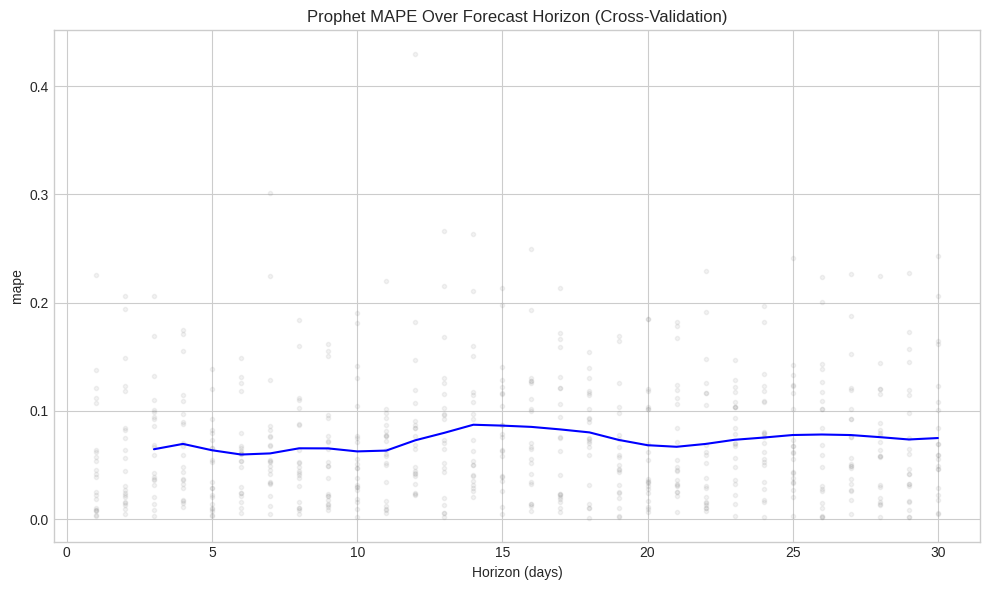


✅ Plot saved: outputs/12_prophet_cv_mape.png


In [39]:
# ============================================================
# CELL 25: PROPHET CROSS-VALIDATION  (fixed)
# ============================================================

# Fix: import explicitly at top of cell
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

print("Running Prophet cross-validation...")
print("This may take 5-10 minutes. Please wait...\n")

df_cv = cross_validation(
    model_prophet,
    initial='1095 days',   # first 3 years for initial training
    period='180 days',     # retrain every 180 days
    horizon='30 days',     # forecast 30 days ahead
    parallel='processes'
)

df_perf = performance_metrics(df_cv)

print("Cross-validation results:")
print(df_perf[['horizon', 'rmse', 'mae', 'mape']].to_string())

# Plot MAPE over forecast horizon
fig = plot_cross_validation_metric(df_cv, metric='mape')
plt.title('Prophet MAPE Over Forecast Horizon (Cross-Validation)')
plt.tight_layout()
plt.savefig('outputs/12_prophet_cv_mape.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved: outputs/12_prophet_cv_mape.png")

In [40]:

print("\n" + "=" * 50)
print("  PROJECT COMPLETE - OUTPUT FILES")
print("=" * 50)

output_files = sorted(os.listdir('outputs'))
for f in output_files:
    fpath = os.path.join('outputs', f)
    size  = os.path.getsize(fpath)
    print(f"  {f:45s} ({size/1024:.1f} KB)")

print("=" * 50)
print(f"\nTotal files saved: {len(output_files)}")
print("\nFinal model metrics:")
print(results.to_string())
print("\nDone! Your energy forecasting project is complete.")




  PROJECT COMPLETE - OUTPUT FILES
  01_raw_consumption.png                        (693.3 KB)
  02_seasonality_patterns.png                   (85.4 KB)
  03_decomposition.png                          (505.8 KB)
  04_acf_pacf.png                               (97.6 KB)
  05_train_test_split.png                       (129.9 KB)
  06_sarima_forecast.png                        (123.3 KB)
  07_sarima_diagnostics.png                     (198.8 KB)
  08_prophet_forecast_full.png                  (508.3 KB)
  09_prophet_components.png                     (213.0 KB)
  10_prophet_test_comparison.png                (168.0 KB)
  11_model_comparison.png                       (170.3 KB)
  12_prophet_cv_mape.png                        (72.4 KB)
  model_results.csv                             (0.1 KB)

Total files saved: 13

Final model metrics:
            RMSE      MAE    MAPE      R2
Model                                    
SARIMA   5735.84  4749.61  29.570 -5.1942
Prophet  2922.45  2358.86  12.75